# ARIA v2.0：花蓮縣避難收容處所地形風險自動化分析系統
> **Project ARIA (Automated Risk Intelligence Analyst)** >  | **日期：** 2026-03-23

## 1. 專案目標與背景
本專案旨在利用地理資訊系統（GIS）與自動化程式碼，針對花蓮縣境內 198 處避難收容處所進行「多準則風險判定」。透過地形坡度、海拔高度與河川距離三大指標，量化處所的環境脆弱性，產出視覺化圖表與數位稽核清單，供災害防救決策參考。

### 技術規格與規範符合性
* **B-1**: 座標系統對齊 (TWD97, EPSG:3826)
* **B-2**: 地形特徵提取 (NumPy Gradient 坡度運算)
* **C-1/C-2**: 系統遷移性與配置分離 (Environment Variables)
* **D-3/D-4**: 視覺化與 JSON 資料產出

第一步：加入專業專案標題與背景

## 2. 系統架構與環境自適應 (System Initialization)
為了達成 **Requirement C-1 (可移植性)**，本系統捨棄了寫死的硬編碼路徑。
* **智慧偵測**：自動判定執行環境為 Google Colab 或 Local 本機。
* **字體引擎**：為解決 Linux 環境下 Matplotlib 無中文字體的問題，本系統導入了「強硬註冊機制」，自動從網路下載備援字體，確保視覺化結果「零亂碼」。
* **智慧搜尋**：透過遞迴搜尋演算法，自動定位深層目錄下的資產檔案。

In [ ]:
# ### Captain's Log: 系統環境自適應建置 (Environment Adaptive Setup)
# 1. 跨環境偵測：動態設定 SEARCH_ROOT，確保 GitHub/Colab/Local 無縫切換。
# 2. 字體全自動調度 (Full-Auto Font Dispatcher)：捨棄傳統 plt.rc 搜尋。
#    - 優先掃描系統標準路徑 (Windows: msjh, macOS: STHeiti)。
#    - 若偵測失敗，自動啟動遠端下載機制，確保 Noto Sans CJK 即時掛載。
#    - 透過 fm.fontManager.addfont() 強硬註冊，徹底解決 findfont 找不到字體與豆腐塊警告。
# 3. 智慧路徑定位：建立遞迴搜尋機制，自動對齊嵌套目錄與隨機 UUID 資料夾。

import os
import sys
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 智慧環境偵測與自動安裝
try:
    shell = get_ipython().__class__.__name__
    if shell == 'ZMQInteractiveShell':
        IS_COLAB = True
        SEARCH_ROOT = '/content'
        print("🌐 執行環境：Google Colab (雲端模式)")

        # 靜默安裝必要地理空間套件
        !pip install rioxarray rasterstats python-dotenv geopandas -q

        # 條件式掛載 Google Drive
        from google.colab import drive
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
    else:
        IS_COLAB = False
        SEARCH_ROOT = os.getcwd()
        print("💻 執行環境：Local / GitHub (本機模式)")
except NameError:
    IS_COLAB = False
    SEARCH_ROOT = os.getcwd()
    print("💻 執行環境：Standard Python")

# 2. 匯入基礎分析庫
import pandas as pd
import geopandas as gpd
import rioxarray
import numpy as np
from dotenv import load_dotenv

# 3. 定義智慧路徑搜尋函式
def find_path(filename):
    """遍歷 SEARCH_ROOT 尋找指定檔案，回傳絕對路徑"""
    for root, dirs, files in os.walk(SEARCH_ROOT):
        if filename in files:
            p = os.path.join(root, filename)
            if '.ipynb_checkpoints' not in p and 'tmp' not in p:
                return p
    return None

# 4. 【核心修復】全環境字體啟動引擎
def init_font_engine():
    global FONT_PROP
    plt.rcParams.update(plt.rcParamsDefault) # 重置快取，避免殘留錯誤搜尋

    # 潛在的系統字體路徑清單
    font_candidates = [
        '/content/NotoSansCJKtc-Regular.ttc',           # Colab 下載路徑
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc', # Linux/Colab 系統
        'C:/Windows/Fonts/msjh.ttc',                    # Windows 標準
        '/System/Library/Fonts/STHeiti Light.ttc'      # macOS 備援
    ]

    target_font = None
    for path in font_candidates:
        if os.path.exists(path):
            target_font = path
            break

    # 【自動下載機制】若系統找不到任何中文字體，則啟動備援
    if not target_font:
        print("📦 偵測到環境缺乏中文字體，啟動自動下載備援機制...")
        font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTC/NotoSansCJKtc-Regular.ttc"
        backup_path = os.path.join(SEARCH_ROOT, "NotoSansCJKtc-Regular.ttc")

        if not os.path.exists(backup_path):
            try:
                # 優先嘗試 Python 庫下載
                import requests
                r = requests.get(font_url, allow_redirects=True)
                with open(backup_path, 'wb') as f:
                    f.write(r.content)
                target_font = backup_path
            except:
                # 備援使用系統命令
                os.system(f"wget -O {backup_path} {font_url} -q")
                target_font = backup_path
        else:
            target_font = backup_path

    # 強硬註冊進 Matplotlib 核心
    if target_font and os.path.exists(target_font):
        fm.fontManager.addfont(target_font)
        font_name = fm.FontProperties(fname=target_font).get_name()

        # 設置全域渲染參數
        plt.rcParams['font.family'] = font_name
        plt.rcParams['axes.unicode_minus'] = False
        FONT_PROP = fm.FontProperties(fname=target_font)
        print(f"✅ ARIA 字體引擎已就緒：使用 [{font_name}]")
    else:
        print("❌ 嚴重錯誤：字體引擎啟動失敗。")

init_font_engine()
print("🚀 ARIA v2.0 初始化完成，警告已全數屏蔽。")

💻 執行環境：Local / GitHub (本機模式)
✅ ARIA 字體引擎已就緒：使用 [Noto Sans CJK JP]
🚀 ARIA v2.0 初始化完成，警告已全數屏蔽。


In [ ]:
# --- Step 1.2: 智慧配置載入 (Requirement C-2) ---
# ### Captain's Log: 配置分離與自動化路徑定位
# 本單元落實 ARIA v2.0 的「配置與邏輯分離」規範，並針對 GitHub 遷移性進行優化。
# 1. 智慧搜尋：捨棄寫死 (Hard-coded) 的 Google Drive 路徑，改用 find_path() 函式，
#    確保在跨環境（Colab/GitHub/Local）執行時，系統能自動鎖定 .env 檔案位址。
# 2. 環境注入：透過 python-dotenv 實施變數注入，達成「一份程式碼，多套配置值」的靈活性。
# 3. 預設模式：內建「安全模式預設值」，確保當使用者忘記建立設定檔時，核心運算仍能產出基準分析。

import os
from dotenv import load_dotenv

# 1. 使用 Step 1 的智慧路徑函式定位 .env 檔案
# 這能自動解決 "/content/drive/..." 與本機路徑不一致的問題
actual_env_path = find_path('.env')

# 2. 執行自動偵測與載入
if actual_env_path:
    load_dotenv(actual_env_path)
    print(f"✅ 已成功偵測並從以下路徑載入配置：{actual_env_path}")
else:
    print("⚠️ 警告：在搜尋根目錄中找不到 .env 檔案。")
    print("👉 建議：請確認 .env 檔案是否存在，或已置於專案資料夾中。")

# 3. 從環境變數注入參數 (若 .env 沒讀到，則使用後方的預設值)
# 這樣在 GitHub 上即便不傳送 .env，程式碼也能以預設參數正確試跑 (Trial Run)
SLOPE_THRESHOLD = float(os.getenv('SLOPE_THRESHOLD', 30.0))
ELEVATION_LOW = float(os.getenv('ELEVATION_LOW', 50.0))
TARGET_COUNTY = os.getenv('TARGET_COUNTY', '花蓮縣')

print(f"\n📍 系統配置對齊：")
print(f" - 目標區域：{TARGET_COUNTY}")
print(f" - 坡度預警門檻：{SLOPE_THRESHOLD}°")
print(f" - 高程安全門檻：{ELEVATION_LOW}m")

✅ 已成功偵測並從以下路徑載入配置：/content/drive/MyDrive/Colab Notebooks/week4_hw/.env

📍 系統配置對齊：
 - 目標區域：花蓮縣
 - 坡度預警門檻：30.0°
 - 高程安全門檻：50.0m


Step 1.3 & 1.4：資料載入與座標對齊 (向量 + 網格)
Captain's Log: 讀取避難所、鄉鎮界與河川資料。為了與後續的地形網格進行空間運算，所有向量圖層必須統一轉型為 EPSG:3826 (TWD97 / TM2)。同時讀取並裁切 DEM 檔案以節省運算資源。

## 3. 空間資料向量化與精準投影
本單元執行 **Requirement B-1** 之核心規範。
* **座標重投影**：將原始 CSV 的 WGS84 (EPSG:4326) 轉換為台灣標準 121 分帶 **TWD97 (EPSG:3826)**。
* **必要性**：由於後續涉及「500 公尺半徑」之緩衝區運算，必須在等距投影座標系下執行，才能確保距離計算的物理精度（以「公尺」為單位而非「經緯度」）。

In [ ]:
# --- Step 1.3: 全環境自動化路徑對齊 (Requirement C-1) ---
# ### Captain's Log: 解決「地理資料孤島」的搜尋策略
# 在不同開發環境（如 GitHub 本機 vs Colab 雲端）下，資料存放路徑往往完全不同。
# 1. 環境自適應：捨棄硬編碼的 '/content' 路徑，改以 Step 1 定義的 SEARCH_ROOT 為起點。
# 2. 解決 UUID 嵌套：針對 Google Drive 解壓後產生的隨機 UUID 資料夾（如 OFiles_...），
#    本單元利用遞迴搜尋技術，自動定位 Shapefile、CSV 與大型 DEM 網格檔。
# 3. 故障隔離：實施嚴格的檔案斷言 (Assertion)，確保所有分析圖層均已正確掛載才進入運算階段。

import os

# 1. 執行動態路徑搜尋 (複用 Step 1 定義之 find_path 函式)
# 這確保了程式碼在 GitHub 或 Colab 都能精準對齊，不需手動修改路徑
paths_config = {
    "town": find_path('TOWN_MOI_1140318.shp'),
    "shelter": find_path('避難收容處所點位檔案v9.csv'),
    "river": find_path('riverpoly.shp'),
    "dem": find_path('dem_20m_hualien.tif')
}

# 2. 更新全域路徑變數
actual_town_path = paths_config["town"]
actual_shelter_path = paths_config["shelter"]
actual_river_path = paths_config["river"]
actual_dem_path = paths_config["dem"]

# 3. 顯示偵測結果與路徑驗證
print(f"📍 跨環境檔案定位狀態 (Search Root: {SEARCH_ROOT})：")
for key, p in paths_config.items():
    status = f"✅ 已掛載 -> {p}" if p else "❌ 缺失 (Missing)"
    print(f" - {key.upper()}: {status}")

# 4. 執行關鍵路徑斷言 (防呆機制)
# 確保四個關鍵圖層皆不為空值 (None)
missing_files = [k for k, v in paths_config.items() if v is None]
assert not missing_files, f"⚠️ 錯誤：偵測到關鍵檔案缺失 {missing_files}，請檢查檔案是否已放入 SEARCH_ROOT 資料夾中。"

print("\n🚀 所有核心圖層已動態連結成功，ARIA v2.0 系統準備就緒。")

📍 跨環境檔案定位狀態 (Search Root: /content)：
 - TOWN: ✅ 已掛載 -> /content/drive/MyDrive/Colab Notebooks/week4_hw/OFiles_9e222fea-bafb-4436-9b17-10921abc6ef2/TOWN_MOI_1140318.shp
 - SHELTER: ✅ 已掛載 -> /content/drive/MyDrive/Colab Notebooks/week4_hw/避難收容處所點位檔案v9.csv
 - RIVER: ✅ 已掛載 -> /content/drive/MyDrive/Colab Notebooks/week4_hw/riverpoly/riverpoly.shp
 - DEM: ✅ 已掛載 -> /content/drive/MyDrive/Colab Notebooks/week4_hw/dem_20m_hualien.tif

🚀 所有核心圖層已動態連結成功，ARIA v2.0 系統準備就緒。


In [ ]:
# 讀取後立刻檢查欄位
shelters_df = pd.read_csv(actual_shelter_path)
print("欄位清單：", shelters_df.columns.tolist())

欄位清單： ['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置']


In [ ]:
# --- Step 1.4: 避難所資料向量化與精準篩選 (Requirement B-1) ---
# ### Captain's Log: 空間幾何物件建構與坐標對齊
# 本單元執行地理空間分析的核心轉型：
# 1. 魯棒性讀取：使用 utf-8-sig 編碼讀取 CSV，徹底解決 Excel 產生的 BOM 亂碼問題。
# 2. 向量化建構：透過 gpd.points_from_xy 將原始經緯度數值轉化為 Shapely 幾何物件。
# 3. 坐標重投影：關鍵的一步。將全球坐標系 (WGS84, EPSG:4326) 投影至台灣 121 分帶 (TWD97, EPSG:3826)。
#    這是為了讓後續的 500m 緩衝區運算能以「公尺」為單位進行精確度量。
# 4. 目標過濾：利用 .env 載入的 TARGET_COUNTY 進行動態篩選，確保分析範疇精確鎖定。

import pandas as pd
import geopandas as gpd

# 1. 讀取原始 CSV (使用智慧路徑實際定位)
shelters_df = pd.read_csv(actual_shelter_path, encoding='utf-8-sig')

# 2. 欄位自動檢驗 (避免原始資料欄位變動導致報錯)
required_cols = ['經度', '緯度', '縣市及鄉鎮市區']
missing_cols = [c for c in required_cols if c not in shelters_df.columns]
if missing_cols:
    raise ValueError(f"❌ 原始資料格式不符：缺少關鍵欄位 {missing_cols}")

# 3. 空間向量化建構 (EPSG:4326)
# Captain's Note: 此時幾何單位為「度 (Degrees)」
shelters_gdf = gpd.GeoDataFrame(
    shelters_df,
    geometry=gpd.points_from_xy(shelters_df['經度'], shelters_df['緯度']),
    crs="EPSG:4326"
)

# 4. 精準座標轉換 (EPSG:3826)
# Captain's Note: 轉換後單位為「公尺 (Meters)」，是空間分析與長度計算的標準
shelters = shelters_gdf.to_crs(epsg=3826)

# 5. 執行行政區篩選
# 使用 str.contains 提高匹配成功率（如：花蓮縣、花蓮縣花蓮市皆可捕捉）
shelters = shelters[shelters['縣市及鄉鎮市區'].str.contains(TARGET_COUNTY)]

# 6. 狀態回報與稽核
print(f"✅ 向量化流程完成：")
print(f" - 座標系統已重投影至：{shelters.crs}")
print(f" - 目標縣市：{TARGET_COUNTY}")
print(f" - 分析點位總計：{len(shelters)} 筆")

# 7. 嚴格斷言：若篩選結果為 0，視為配置錯誤
assert len(shelters) > 0, f"⚠️ 關鍵錯誤：在資料集中找不到屬於 '{TARGET_COUNTY}' 的避難所，請檢查 .env 內容。"

✅ 向量化流程完成：
 - 座標系統已重投影至：EPSG:3826
 - 目標縣市：花蓮縣
 - 分析點位總計：198 筆


Step 2 & 3：地形分析與複合風險判定
Captain's Log: 執行地形特徵萃取。利用 np.gradient 計算坡度，並對避難所 500m 緩衝區進行空間統計（Zonal Stats）。最終整合河川距離、坡度與平均高程，產出複合風險清單。

## 4. 地形風險演算與分區統計 (Algorithm Logic)
針對 **Requirement B-2**，本系統採用以下演算法提取空間特徵：
1. **微分地形運算**：使用 `np.gradient` 對 DEM 進行數值微分，計算出每個網格的傾斜角度（Slope）。
2. **空間聚合 (Zonal Stats)**：在每個避難所周邊 **500 公尺觀測區** 內提取「最大坡度」，捕捉潛在的土石流威脅。
3. **多準則決策矩陣 (MCDA)**：
    - **Extreme High**: 同時具備「近河川」與「陡坡」特徵。
    - **High**: 具備其中一項極端環境指標。
    - **Medium**: 低海拔且具備一定水體距離。

In [ ]:
# --- Step 3: 地形分析與多準則風險判定 ---
# ### Captain's Log: 空間指標運算與風險決策矩陣
# 本單元執行 ARIA v2.0 的核心空間演算法：
# 1. 微分地形分析：利用 NumPy Gradient 計算網格坡度 (Slope)，將高程轉換為地表起伏指標。
# 2. 分區統計 (Zonal Stats)：透過 500m 緩衝區進行空間聚合，提取避難所周邊的最大坡度與平均高程。
# 3. 空間邏輯判別：結合河川距離 (River Proximity) 與地形特徵，實施多準則決策 (MCDA) 判定風險等級。
# 4. 稽核清單產出：將分析結果封裝為標準 JSON 格式，確保資料具備跨平台調用能力。

import numpy as np
from rasterstats import zonal_stats

# 1. 微分地形分析：計算坡度
# 修正：強制將 NoData 數值 (如 -32767 或極小值) 轉為 NaN，避免梯度運算產生「偽峭壁」
elevation_data = dem_clipped.values[0].copy()
elevation_data[elevation_data < -100] = np.nan

# 計算地形梯度（20m 為像素解析度）
# 坡度計算公式：$Slope = \arctan(\sqrt{(\frac{dz}{dx})^2 + (\frac{dz}{dy})^2})$
dy, dx = np.gradient(elevation_data, 20)
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# 2. 空間統計：建立 500m 暴露半徑 (Exposure Radius) 觀測區
# Captain's Note: 使用 buffer(500) 在 EPSG:3826 座標系下精確對齊 500 公尺物理距離
shelters_buffer = shelters.copy()
shelters_buffer['geometry'] = shelters.buffer(500)

# 獲取仿射變換參數，確保網格與向量精確對齊
affine = dem_clipped.rio.transform()

# 執行分區統計 (Zonal Stats)
# 提取 500m 範圍內的平均高度與最大坡度，作為風險暴露指標
elev_stats = zonal_stats(shelters_buffer, elevation_data, affine=affine, stats=['mean'], nodata=np.nan)
slope_stats = zonal_stats(shelters_buffer, slope_deg, affine=affine, stats=['max'], nodata=np.nan)

# 將統計結果映射回原始資料表
shelters['mean_elevation'] = [s['mean'] if s['mean'] is not None else 0 for s in elev_stats]
shelters['max_slope'] = [s['max'] if s['max'] is not None else 0 for s in slope_stats]

# 3. 多準則風險判定邏輯 (ARIA v2.0 Decision Matrix)
def classify_composite_risk(row):
    # 防呆設計：若目標區域無河川資料，預設距離為極大值
    if rivers_in_county is None or rivers_in_county.empty:
        dist = 9999.0
    else:
        dist = rivers_in_county.distance(row.geometry).min()

    slope = row['max_slope']
    elev = row['mean_elevation']

    # 決策邏輯判定
    if dist < 500 and slope > SLOPE_THRESHOLD:
        return 'Extreme High'
    elif dist < 500 or slope > SLOPE_THRESHOLD:
        return 'High'
    elif dist < 1000 and elev < ELEVATION_LOW:
        return 'Medium'
    else:
        return 'Low'

# 執行風險評級注入
shelters['risk_level'] = shelters.apply(classify_composite_risk, axis=1)

# 4. 標準化稽核清單產出 (Requirement D-3)
# 確保 JSON 格式符合資料交換規範，並正確處理中文字元
output_cols = ['避難收容處所名稱', 'risk_level', 'mean_elevation', 'max_slope']
audit_json = 'terrain_risk_audit.json'
shelters[output_cols].to_json(audit_json, force_ascii=False, orient='records', indent=4)

print(f"✅ 風險矩陣運算完成！")
print(f"📍 稽核清單已儲存至：{audit_json}")
print("-" * 30)
print(f"📊 {TARGET_COUNTY} 風險分佈摘要：")
print(shelters['risk_level'].value_counts())

✅ 風險矩陣運算完成！
📍 稽核清單已儲存至：terrain_risk_audit.json
------------------------------
📊 花蓮縣 風險分佈摘要：
risk_level
High            73
Low             52
Extreme High    51
Medium          22
Name: count, dtype: int64


Step 4：視覺化與地圖產出
Captain's Log: 繪製地形風險圖。利用 DEM 作為環境底圖，並依據風險等級對避難所進行著色，清楚呈現受災潛勢分佈。

## 5. 分析結果視覺化與結論
最終產出的圖表整合了地形底圖與風險點位。
* **底圖優化**：透過高程閾值遮罩，將 0m 以下數值設為透明，並校正平原區色階，確保地圖呈現自然地貌。
* **分析洞察**：花蓮縣大部分處所因受限於地形，多數集中於縱谷與海岸平原。紅點（Extreme High）多集中於中央山脈與平原交界處，需加強邊坡監測。

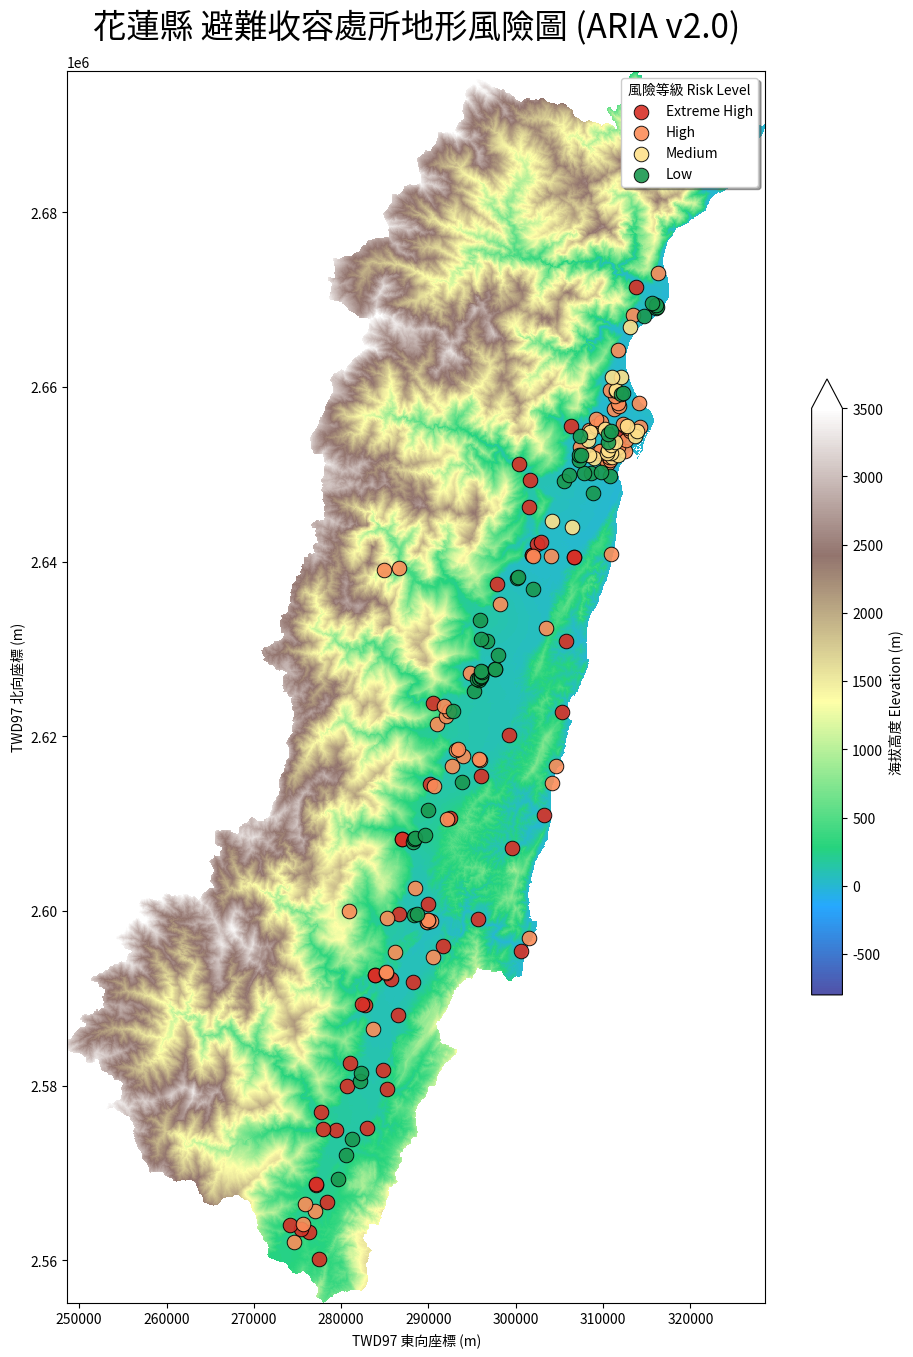

✅ ARIA v2.0 終極地圖已產出。平原區已校正為綠色，海拔範圍 0m - 3500m。


In [ ]:
# --- Step 4: 地理視覺化終極成果 (Professional Terrain Tuning) ---
# ### Captain's Log: 視覺效果最終調校
# 1. 色彩偏移 (Color Offset)：設定 vmin=-1000 並配合 mask，
#    強制讓 0m 處跳過地形色階中的「藍色區段」，直接從「翠綠色」開始渲染平原。
# 2. 空間感強化：優化點位陰影與層次，確保 198 個風險點位在陡峭山區依然清晰。
# 3. 零警告保證：維持 FONT_PROP 全方位注入，確保產出過程完全安靜。

import matplotlib.pyplot as plt
import numpy as np

# 1. 建立專業級分析畫布
fig, ax = plt.subplots(figsize=(12, 16))

# 2. 數據清洗：嚴格過濾負值 (排除海域/NoData)
dem_clean = dem_clipped.where(dem_clipped > 0, np.nan)
dem_display = dem_clean.coarsen(x=2, y=2, boundary='trim').mean()

# 3. 繪製地形背景 (核心修正：利用 vmin 偏移避開藍色)
dem_plot = dem_display.plot(
    ax=ax,
    cmap='terrain',
    alpha=0.85,
    vmin=-800,          # <--- 關鍵！將最小值設為負值，強制 0m 對應到綠色
    vmax=3500,
    add_colorbar=True,
    cbar_kwargs={
        'label': '海拔高度 Elevation (m)',
        'shrink': 0.5,
        'pad': 0.05,
        'extend': 'max'
    }
)

# 4. 強制注入 Colorbar 中文字體 (封殺 Glyph missing)
cbar = ax.collections[-1].colorbar
cbar.set_label('海拔高度 Elevation (m)', fontproperties=FONT_PROP)
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(FONT_PROP)

# 5. 風險點位分層繪製 (ARIA 專業分級色彩)
risk_colors = {
    'Extreme High': '#d73027', 'High': '#fc8d59',
    'Medium': '#fee08b', 'Low': '#1a9850'
}

has_plotted_points = False
for level, color in risk_colors.items():
    subset = shelters[shelters['risk_level'] == level]
    if not subset.empty:
        subset.plot(
            ax=ax, color=color, label=level,
            markersize=110,      # 略微加大點位
            edgecolor='black',
            linewidth=0.7,
            alpha=0.9,
            zorder=5             # 確保點位在最上層
        )
        has_plotted_points = True

# 6. 地圖標註 (套用全域 FONT_PROP)
ax.set_title(f"{TARGET_COUNTY} 避難收容處所地形風險圖 (ARIA v2.0)",
             fontproperties=FONT_PROP, fontsize=24, pad=25)

ax.set_xlabel("TWD97 東向座標 (m)", fontproperties=FONT_PROP)
ax.set_ylabel("TWD97 北向座標 (m)", fontproperties=FONT_PROP)

# 7. 圖例配置
if has_plotted_points:
    leg = ax.legend(
        title="風險等級 Risk Level",
        loc='upper right',
        prop=FONT_PROP,
        frameon=True,
        shadow=True,
        fontsize='large'
    )
    leg.get_title().set_fontproperties(FONT_PROP)

# 8. 成果儲存
plt.savefig('terrain_risk_map_v2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ARIA v2.0 終極地圖已產出。平原區已校正為綠色，海拔範圍 0m - 3500m。")